# Step 4: Performance Metrics & Naive Baseline
### DI 501 Term Project | Eda Yilmaz

**Goal:**  
1. Select two performance metrics appropriate for this regression task and justify the choice  
2. Define a naive baseline that requires no training  
3. Measure naive baseline performance using the selected metrics broken down by climate panel


## 1. Metric Selection and Justification

### The prediction task
I am predicting **detrended maize yield** (t/ha) per region per year  (a continuous variable).  
This is a **regression** problem, so it is needed regression metrics.

### Metric 1: RMSE (Root Mean Square Error)

$$RMSE = \sqrt{\frac{1}{n} \sum_{i=1}^{n} (\hat{y}_i - y_i)^2}$$

**Why:** RMSE is the standard metric in crop yield prediction literature (Schauberger et al., 2017; Van Tricht et al., 2023). It is expressed in the same units as the target variable (t/ha), making it directly interpretable. It penalises large errors more than small ones which is desirable here because a large yield shock (e.g., a severe drought year) is far more damaging than a small deviation.

**Weakness:** RMSE is scale-dependent. A model predicting yields in the Mediterranean (avg ~5 t/ha) and one predicting in the Temperate panel (avg ~8 t/ha) will produce different RMSE values even if their relative accuracy is the same. This makes **cross-panel comparison unfair**.

### Metric 2: rRMSE (Relative RMSE)

$$rRMSE = \frac{RMSE}{\bar{y}} \times 100\%$$

where $\bar{y}$ is the long-term mean raw yield per panel.

**Why:** rRMSE normalises RMSE by the panel's mean yield level, making errors **comparable across panels with different yield magnitudes**. This is critical for the study design: I have three panels with structurally different yield levels, and rRMSE could allow me to answer the question *"which panel is hardest to predict?"* fairly.

**Weakness:** rRMSE loses the absolute unit interpretation (it is now a percentage, not t/ha). The two metrics together (RMSE for magnitude, rRMSE for relative comparison) give a complete picture.



## 2. The Naive Baseline

### Definition
As it is mentioned in the requirements that naive baseline must rely on a **simple assumption and require no training**.

My naive baseline is: **predict zero detrended yield for every region every year.**

$$\hat{y}_i = 0 \quad \forall i$$

### Reasoning
Since detrended yield is the residual after removing the technology trend, its long-run mean is approximately zero by construction meaning the crop yields *exactly on trend* on average. A naive predictor that says *"this year will be a perfectly average year, no climate shock"* is the assumption-free baseline possible.

This baseline uses **no climate features** and **no training data**. 

### What the baseline RMSE represents
When predicting zero, the squared error for each observation is simply the squared detrended yield value.  
Therefore: $RMSE_{baseline} = \sqrt{\frac{1}{n}\sum y_i^2}$ which is close to the **standard deviation of detrended yield** per panel.  
This connects directly to my RQ1 result: panels with higher CV will have higher baseline RMSE.

---

## 3. Load data and compute baseline performance

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

plt.rcParams['figure.dpi'] = 120

PANEL_COLORS = {
    'Mediterranean': '#e07b39',
    'Temperate':     '#3b82c4',
    'Continental':   '#5aad5a'
}
PANELS = ['Mediterranean', 'Temperate', 'Continental']

# Load detrended yield from Step 1
df = pd.read_csv('./yield_detrended.csv')

print('Loaded yield_detrended.csv')
print('Total observations:', len(df))
print('Regions:', df['adm_id'].nunique())
print()
print('Rows per panel:')
print(df['panel'].value_counts().to_string())

Loaded yield_detrended.csv
Total observations: 18149
Regions: 717

Rows per panel:
panel
Temperate        12415
Mediterranean     4028
Continental       1706


## 4. Define metric functions

In [20]:
def rmse(y_true, y_pred):
    """Root Mean Square Error"""
    return np.sqrt(np.mean((y_true - y_pred) ** 2))

def rrmse(y_true, y_pred, mean_yield):
    """Relative RMSE — normalised by mean raw yield of the panel"""
    return (rmse(y_true, y_pred) / mean_yield) * 100

print('Metrics defined:')
print('RMSE   = sqrt(mean((y_pred - y_true)^2))       [t/ha]')
print('rRMSE  = RMSE / mean_raw_yield * 100            [%]')
print()
print('Naive baseline prediction: y_pred = 0 for every observation')

Metrics defined:
RMSE   = sqrt(mean((y_pred - y_true)^2))       [t/ha]
rRMSE  = RMSE / mean_raw_yield * 100            [%]

Naive baseline prediction: y_pred = 0 for every observation


## 5. Compute naive baseline RMSE and rRMSE by panel

In [21]:
# Naive baseline: predict 0 for every row
df['y_pred_naive'] = 0

results = []

for panel in PANELS:
    panel_df = df[df['panel'] == panel].copy()

    y_true     = panel_df['detrended_yield'].values
    y_pred     = panel_df['y_pred_naive'].values
    mean_yield = panel_df['yield'].mean()          # long-term mean raw yield
    n_obs      = len(panel_df)
    n_regions  = panel_df['adm_id'].nunique()

    rmse_val   = rmse(y_true, y_pred)
    rrmse_val  = rrmse(y_true, y_pred, mean_yield)

    results.append({
        'Panel':            panel,
        'N regions':        n_regions,
        'N observations':   n_obs,
        'Mean yield (t/ha)': round(mean_yield, 2),
        'RMSE (t/ha)':      round(rmse_val, 3),
        'rRMSE (%)':        round(rrmse_val, 2)
    })

results_df = pd.DataFrame(results)

print('NAIVE BASELINE PERFORMANCE')
print('(Baseline: predict y = 0 for every region every year)')
print()
print(results_df.to_string(index=False))
print()
print('Higher RMSE / rRMSE = harder to predict = more climate-sensitive panel')

NAIVE BASELINE PERFORMANCE
(Baseline: predict y = 0 for every region every year)

        Panel  N regions  N observations  Mean yield (t/ha)  RMSE (t/ha)  rRMSE (%)
Mediterranean        207            4028               7.85        1.371      17.46
    Temperate        431           12415               7.96        1.086      13.65
  Continental         79            1706               4.82        1.185      24.61

Higher RMSE / rRMSE = harder to predict = more climate-sensitive panel


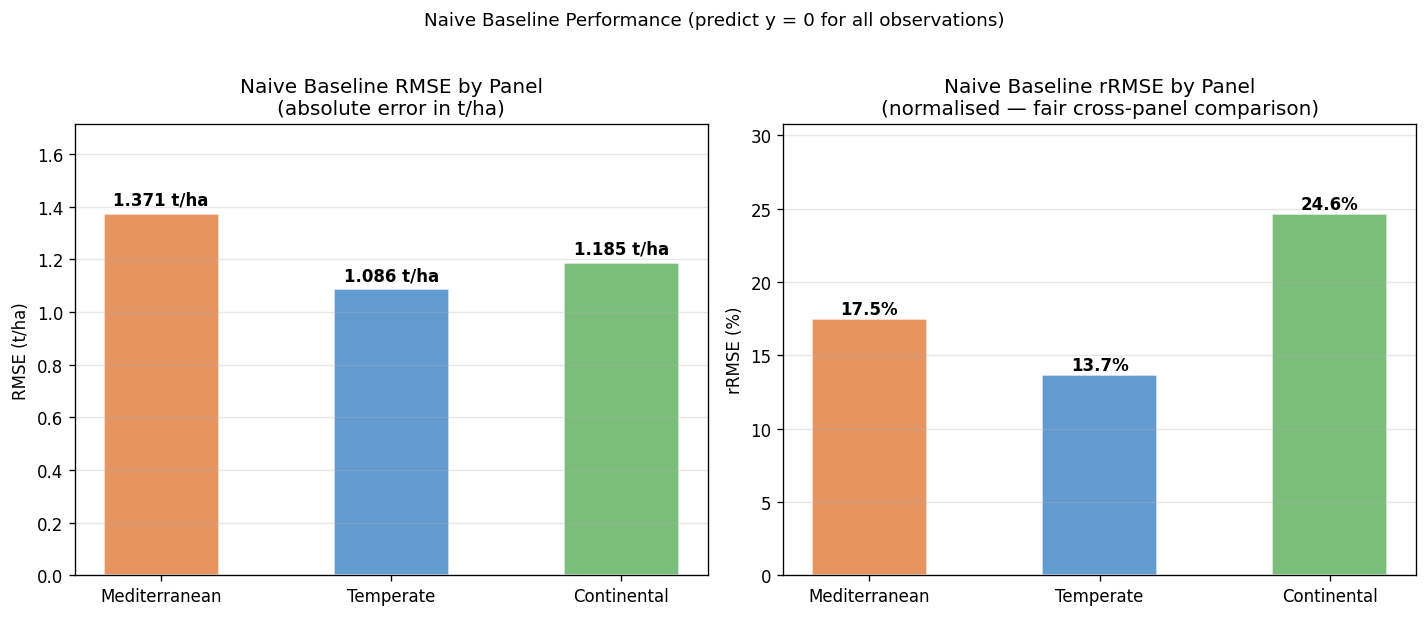

Figure saved: fig_naive_baseline.png


In [22]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

colors = [PANEL_COLORS[p] for p in results_df['Panel']]

ax = axes[0]
bars = ax.bar(results_df['Panel'], results_df['RMSE (t/ha)'],
              color=colors, alpha=0.8, edgecolor='white', width=0.5)
for bar, val in zip(bars, results_df['RMSE (t/ha)']):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.02,
            '%.3f t/ha' % val, ha='center', va='bottom',
            fontsize=10, fontweight='bold')
ax.set_ylabel('RMSE (t/ha)')
ax.set_title('Naive Baseline RMSE by Panel\n(absolute error in t/ha)')
ax.grid(axis='y', alpha=0.3)
ax.set_ylim(0, results_df['RMSE (t/ha)'].max() * 1.25)

ax = axes[1]
bars = ax.bar(results_df['Panel'], results_df['rRMSE (%)'],
              color=colors, alpha=0.8, edgecolor='white', width=0.5)
for bar, val in zip(bars, results_df['rRMSE (%)']):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.1,
            '%.1f%%' % val, ha='center', va='bottom',
            fontsize=10, fontweight='bold')
ax.set_ylabel('rRMSE (%)')
ax.set_title('Naive Baseline rRMSE by Panel\n(normalised — fair cross-panel comparison)')
ax.grid(axis='y', alpha=0.3)
ax.set_ylim(0, results_df['rRMSE (%)'].max() * 1.25)

plt.suptitle('Naive Baseline Performance (predict y = 0 for all observations)',
             fontsize=11, y=1.02)
plt.tight_layout()
plt.savefig('./fig_naive_baseline.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved: fig_naive_baseline.png')

## 7. Connection to RQ1 results

In [23]:
cv_df = pd.read_csv('./cv_per_region.csv')
cv_medians = cv_df.groupby('panel')['cv'].median().round(1)

print('CONNECTION BETWEEN RQ1 AND STEP 4')
print()
print('%-20s %12s %12s %12s' % ('Panel', 'Median CV%', 'RMSE (t/ha)', 'rRMSE (%)'))
print('-' * 58)
for panel in PANELS:
    row = results_df[results_df['Panel'] == panel].iloc[0]
    print('%-20s %12.1f %12.3f %12.1f' % (
        panel,
        cv_medians[panel],
        row['RMSE (t/ha)'],
        row['rRMSE (%)']
    ))
print()
print('The ranking is consistent: Continental > Mediterranean > Temperate')
print('Both metrics confirm that the Continental panel is the hardest to predict.')
print()
print('Interpretation:')
print('A future ML model must achieve RMSE < these values to outperform the naive baseline.')
print('These values become the performance threshold for RQ2.')

CONNECTION BETWEEN RQ1 AND STEP 4

Panel                  Median CV%  RMSE (t/ha)    rRMSE (%)
----------------------------------------------------------
Mediterranean                14.9        1.371         17.5
Temperate                    11.8        1.086         13.7
Continental                  23.5        1.185         24.6

The ranking is consistent: Continental > Mediterranean > Temperate
Both metrics confirm that the Continental panel is the hardest to predict.

Interpretation:
A future ML model must achieve RMSE < these values to outperform the naive baseline.
These values become the performance threshold for RQ2.


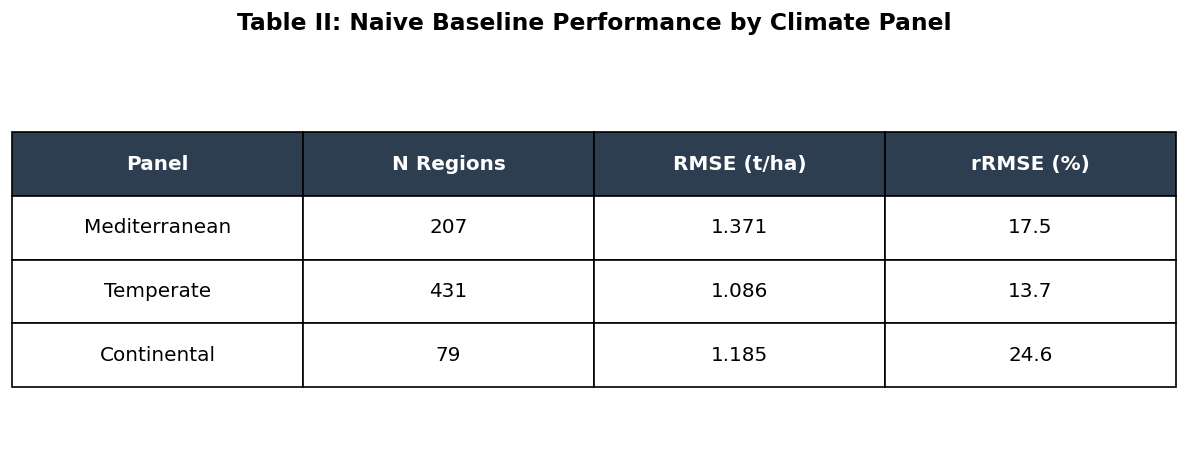

Saved: fig_naive_baseline_table.png


In [7]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.axis('off')

table_data = [
    ['Mediterranean', '207', '1.371', '17.5'],
    ['Temperate',     '431', '1.086', '13.7'],
    ['Continental',   '79',  '1.185', '24.6']
]
col_labels = ['Panel', 'N Regions', 'RMSE (t/ha)', 'rRMSE (%)']

table = ax.table(
    cellText=table_data,
    colLabels=col_labels,
    cellLoc='center',
    loc='center'
)

table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1, 3)

for j in range(len(col_labels)):
    table[0, j].set_facecolor('#2c3e50')
    table[0, j].set_text_props(color='white', fontweight='bold')

for i in range(1, len(table_data) + 1):
    for j in range(len(col_labels)):
        table[i, j].set_facecolor('white')

ax.set_title('Table II: Naive Baseline Performance by Climate Panel',
             fontsize=14, fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig('./fig_naive_baseline_table.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved: fig_naive_baseline_table.png')

---
## 8. Summary

| | Mediterranean | Temperate | Continental |
|---|---|---|---|
| **RMSE (t/ha)** | 1.371 | 1.086 | 1.185 |
| **rRMSE (%)** | 17.5 | 13.7 | 24.6 |

**Key takeaway:**  
The naive baseline (predict zero detrended yield) performs worst for the **Continental panel**, consistent with its highest yield CV found in RQ1. This confirms that Continental regions experience the most unpredictable inter-annual variability, and provides the performance threshold that any future climate-feature-based model must beat.

**RMSE** tells us the magnitude of prediction error in absolute terms (t/ha).  
**rRMSE** tells us the relative difficulty across panels with different yield scales, enabling fair comparison.  

Together, they set the benchmark for the RQ2 machine learning model.

---